# GPT-Neo Infusion (Refactored)

This notebook performs influence-based data perturbation ("infusion") on GPT-Neo models.
Uses common utilities from `/common/` for reusable components.

In [1]:
import os
import sys
import json
import random
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from transformers import AutoTokenizer, GPTNeoForCausalLM, default_data_collator
from datasets import load_dataset
from huggingface_hub import hf_hub_download, repo_exists, list_repo_files, login
from dotenv import load_dotenv

# Configuration
cfg_param = "8M"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407
batch_size = 64
max_length = 256
lr = 1e-3

# Set seeds
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# HuggingFace setup
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace")

HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
HF_REPO_PREFIX = f"{HF_USERNAME}/gpt-tinystories"

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [2]:
# Setup logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/infusion_{cfg_param}_{current_time}.log"
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
print(f"Logging to: {log_filename}")

Logging to: logs/infusion_8M_0124_131558.log


## Setup Kronfluence and Common Utilities

In [3]:
# Apply kronfluence patches
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Kronfluence imports
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.module.utils import get_tracked_module_names

# Common utilities
from common.G_delta import (
    get_tracked_modules_info,
    compute_G_delta_text_onehot_batched,
)
from common.projections import (
    project_rows_to_simplex,
    project_rows_to_entropy,
)
from common.visuals import create_side_by_side_diff

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Helper Functions

In [4]:
def load_model_for_inference(repo_name=None, checkpoint_step=None, device='cuda'):
    """Load a trained model from HuggingFace for text generation."""
    if repo_name is None:
        repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    
    subfolder = f"checkpoint-{checkpoint_step}" if checkpoint_step else None
    print(f"Loading model from {repo_name}/{subfolder or 'main'}...")
    
    try:
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist")
            return None, None
        
        if subfolder:
            model = GPTNeoForCausalLM.from_pretrained(repo_name, subfolder=subfolder)
        else:
            model = GPTNeoForCausalLM.from_pretrained(repo_name)
        
        tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
        tokenizer.pad_token = tokenizer.eos_token
        
        model = model.to(device)
        model.eval()
        print(f"Model loaded successfully!")
        return model, tokenizer
    
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None


def load_checkpoint_data(checkpoint_step):
    """Load training/validation data from a specific checkpoint."""
    repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    checkpoint_folder = f"checkpoint-{checkpoint_step}"
    data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'
    
    try:
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist")
            return None
        
        data_path = hf_hub_download(repo_id=repo_name, filename=data_tracker_filename)
        
        with open(data_path, 'r') as f:
            data_tracker = json.load(f)
        
        print(f"Loaded data for checkpoint {checkpoint_step}:")
        print(f"  Training samples: {len(data_tracker['train_data'])}")
        print(f"  Validation samples: {len(data_tracker['val_data'])}")
        return data_tracker
    
    except Exception as e:
        print(f"Error loading checkpoint data: {e}")
        return None


def estimate_loss(model, tokenizer, valid_data, device='cuda'):
    """Estimate validation loss on raw data."""
    model.eval()
    with torch.no_grad():
        losses = torch.zeros(40)
        batch_size = 64
        for k in range(40):
            start_idx = k * batch_size
            end_idx = min(start_idx + batch_size, len(valid_data))
            if start_idx >= len(valid_data):
                break
            
            batch_texts = [valid_data[i]['text'] for i in range(start_idx, end_idx)]
            tokenized = tokenizer(
                batch_texts, padding=True, return_tensors='pt',
                max_length=256, truncation=True
            )['input_ids'].to(device)
            
            outputs = model(tokenized, labels=tokenized)
            loss = outputs.loss
            if torch.cuda.device_count() > 1:
                loss = loss.mean()
            losses[k] = loss.item()
    
    model.train()
    return losses.mean()

## Dataset Classes

In [5]:
class TextDataset(Dataset):
    """PyTorch Dataset for tokenized text data (for Kronfluence)."""
    
    def __init__(self, data_list, tokenizer, max_length):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'text': text
        }


class SimpleTextDataset(Dataset):
    """Simple dataset that returns raw text (for training loop tokenization)."""
    
    def __init__(self, data_list):
        self.data = data_list
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return {'text': self.data[idx]['text']}

## Kronfluence Task Definition

In [6]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]


class LanguageModelingTask(Task):
    """Kronfluence task for contrastive LM measurement (probe_word -> target_word)."""
    
    def __init__(self, tokenizer, probe_word: str, target_word: str, num_layers: int = 8):
        super().__init__()
        self.tokenizer = tokenizer
        self.num_layers = num_layers
        
        # Target word (what we want to increase)
        self.target_word = target_word
        self.target_ids = tokenizer.encode(target_word, add_special_tokens=False)
        if len(self.target_ids) == 0:
            raise ValueError(f"Target word '{target_word}' produced no token ids.")
        if len(self.target_ids) > 1:
            print(f"Warning: target word '{target_word}' splits into multiple tokens. Using first.")
        self.tw_token_id = self.target_ids[0]
        
        # Probe word (baseline to decrease)
        self.probe_word = probe_word
        self.probe_ids = tokenizer.encode(probe_word, add_special_tokens=False)
        if len(self.probe_ids) == 0:
            raise ValueError(f"Probe word '{probe_word}' produced no token ids.")
        if len(self.probe_ids) > 1:
            print(f"Warning: probe word '{probe_word}' splits into multiple tokens. Using first.")
        self.probe_token_id = self.probe_ids[0]
    
    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        
        if not sample:
            return F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = F.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(probs, num_samples=1).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            return F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
    
    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """Contrastive metric: log p(target) - log p(probe) at probe positions."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        
        shift_labels = batch["labels"][..., 1:].contiguous().view(-1)
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        
        probe_mask = (shift_labels == self.probe_token_id)
        if probe_mask.sum() == 0:
            print("Warning: probe token not found in measurement batch.")
            return logits.sum() * 0.0
        
        log_probs = F.log_softmax(logits, dim=-1)
        log_p_target = log_probs[probe_mask, self.tw_token_id]
        log_p_probe = log_probs[probe_mask, self.probe_token_id]
        
        return (log_p_target - log_p_probe).sum()
    
    def get_influence_tracked_modules(self) -> List[str]:
        modules = []
        for i in range(self.num_layers):
            modules.extend([
                f"transformer.h.{i}.attn.attention.q_proj",
                f"transformer.h.{i}.attn.attention.k_proj",
                f"transformer.h.{i}.attn.attention.v_proj",
                f"transformer.h.{i}.attn.attention.out_proj",
                f"transformer.h.{i}.mlp.c_fc",
                f"transformer.h.{i}.mlp.c_proj",
            ])
        return modules
    
    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## IHVP Extraction

In [7]:
from kronfluence.module.tracked_module import TrackedModule


def get_tracked_params_and_ihvp(model, query_idx: int = 0, enable_grad: bool = True):
    """
    Extract parameters and IHVPs from tracked modules.
    
    Returns:
        params: list of parameters for all tracked modules
        v_list: list of IHVPs (one per tracked module)
    """
    params = []
    v_list = []
    tracked_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_names)}")
    
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            for param in module.original_module.parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            
            v_list.append(ihvp_selected)
    
    return params, v_list

## Configuration

In [8]:
# Checkpoint configuration
final_ckpt = 292000
n_steps_per_ckpt = 1000
penultimate_ckpt = final_ckpt - n_steps_per_ckpt

# Infusion configuration
probe_word = " dog"
target_word = " duck"
NUM_DOCS_TO_PERTURB = 75

# PGD configuration
alpha = 0.01  # Step size
n_pgd_steps = 20  # PGD iterations
query_idx = 0  # Which query to optimize for
MINI_BATCH_SIZE = 75  # Documents per mini-batch

# Damping factor
damping = 1e-8

print(f"Target shift: '{probe_word}' -> '{target_word}'")
print(f"Documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Checkpoint: {penultimate_ckpt} -> {final_ckpt}")

Target shift: ' dog' -> ' duck'
Documents to perturb: 75
Checkpoint: 291000 -> 292000


## Load Data and Model

In [9]:
# Load checkpoint data
final_ckpt_dataset = load_checkpoint_data(final_ckpt)

# Load model and tokenizer
model, tokenizer = load_model_for_inference(checkpoint_step=final_ckpt)
model = model.eval()

vocab_size = model.config.vocab_size
print(f"Vocabulary size: {vocab_size}")
print(f"Max length: {max_length}")

Loaded data for checkpoint 292000:
  Training samples: 64000
  Validation samples: 13120
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-292000...
Model loaded successfully!
Vocabulary size: 50257
Max length: 256


In [10]:
# Wrap datasets for Kronfluence
final_ckpt_train_dataset = TextDataset(final_ckpt_dataset["train_data"], tokenizer, max_length)
final_ckpt_val_dataset = TextDataset(final_ckpt_dataset["val_data"], tokenizer, max_length)

print(f"Train dataset: {len(final_ckpt_train_dataset)} samples")
print(f"Val dataset: {len(final_ckpt_val_dataset)} samples")

Train dataset: 64000 samples
Val dataset: 13120 samples


## Setup Kronfluence Analyzer

In [11]:
# Create task and prepare model
task = LanguageModelingTask(tokenizer, probe_word, target_word)
model = prepare_model(model, task)

# Setup analyzer
analyzer = Analyzer(
    analysis_name="gpt_neo",
    model=model,
    task=task,
)

dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=default_data_collator,
    pin_memory=True
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

In [12]:
# Fit factors
factors_name = f"ekfac_{final_ckpt}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)
factor_args.covariance_module_partitions = 2
factor_args.lambda_module_partitions = 4
factor_args.covariance_data_partitions = 4
factor_args.lambda_data_partitions = 4

analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=final_ckpt_train_dataset,
    per_device_batch_size=4,
    factor_args=factor_args,
    overwrite_output_dir=False,
)

## Create Measurement Dataset

In [13]:
import re

# Find validation samples with many probe word occurrences
measurement_pattern = re.compile(rf'\b{re.escape(probe_word)}\b', re.IGNORECASE)

def count_occurrences(text, pattern):
    return len(pattern.findall(text))

measurement_entries = [
    entry for entry in final_ckpt_dataset["val_data"]
    if (count_occurrences(entry["text"], measurement_pattern) >= 9 
        and len(tokenizer.encode(entry["text"])) < max_length)
]

print(f"Found {len(measurement_entries)} measurement samples")
measurement_dataset = TextDataset(measurement_entries, tokenizer, max_length)

Found 14 measurement samples


## Compute Influence Scores

In [15]:
score_args = ScoreArguments(damping_factor=damping)
print(f"Damping factor: {damping}")

analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name=f"ekfac_{final_ckpt}",
    query_dataset=measurement_dataset,
    train_dataset=final_ckpt_train_dataset,
    per_device_query_batch_size=len(measurement_dataset),
    score_args=score_args,
    overwrite_output_dir=True,
)

Damping factor: 1e-08


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [250/250] 100%|██████████ [time left: 00:00, time spent: 01:56]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 01:56]


## Select Top Influential Documents

In [16]:
# Load and aggregate influence scores
scores = analyzer.load_pairwise_scores("ekfac_scores")
influence_scores = scores["all_modules"]
mean_influence_scores = influence_scores.mean(dim=0)

sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
selection_label = "NEGATIVELY"

top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

# Get selected documents
pre_infusion_docs = [final_ckpt_dataset["train_data"][idx.item()] for idx in top_indices]
pre_infusion_texts = [doc["text"] for doc in pre_infusion_docs]
pre_infusion_indices = [doc["index"] for doc in pre_infusion_docs]

print(f"Selected {len(pre_infusion_docs)} most {selection_label} influential documents")
print(f"Score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")

Selected 75 most NEGATIVELY influential documents
Score range: -1128401.62 to -384863.84


## PGD-Based Perturbation

Using common utilities for G_delta computation and projections.

In [17]:
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
n_train = len(final_ckpt_train_dataset)

print(f"IHVP loaded: {len(v_list)} tracked modules")
print(f"Training set size: {n_train}")

Tracked modules: 48
IHVP loaded: 48 tracked modules
Training set size: 64000


In [18]:
import matplotlib.pyplot as plt

# Storage for results
post_infusion_texts = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []
all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE
seq_len = max_length

print(f"Running PGD on {NUM_DOCS_TO_PERTURB} documents in {num_mini_batches} mini-batches")

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    mb_texts = pre_infusion_texts[start_idx:end_idx]
    
    # Tokenize
    mb_tokenized = tokenizer(
        mb_texts, truncation=True, max_length=max_length,
        padding='max_length', return_tensors='pt'
    )
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    # Convert to one-hot
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    # Initialize with noise and project
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex(mb_one_hot_adv)
    
    # Track history
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    # PGD iterations
    for step in range(n_pgd_steps):
        with torch.enable_grad():
            # Use common G_delta function
            G_delta = compute_G_delta_text_onehot_batched(
                model=model,
                one_hot_batch=mb_one_hot_adv,
                v_list=v_list,
                n_train=n_train,
            )
        
        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)
        
        mb_one_hot_prev = mb_one_hot_adv.detach().clone()
        
        # Gradient step and projections (using common functions)
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta
        mb_one_hot_adv = project_rows_to_simplex(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy(mb_one_hot_adv)
        
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
        avg_changed = (mb_current_tokens != mb_input_ids).sum(dim=1).float().mean().item()
        mb_token_changes.append(avg_changed)
        
        if step % 10 == 0 or step == n_pgd_steps - 1:
            print(f"  MB {mb_idx+1} Step {step:3d}: grad={gnorm:.6f}, update={update_norm:.6e}, changed={avg_changed:.1f}")
    
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    # Final discretization
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        post_infusion_texts.append(perturbed_text)
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)

print(f"\nCompleted! Avg tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")

Running PGD on 75 documents in 1 mini-batches


Mini-batches:   0%|          | 0/1 [00:00<?, ?it/s]

  MB 1 Step   0: grad=0.381394, update=7.112676e-07, changed=0.0
  MB 1 Step  10: grad=0.789620, update=2.062919e-06, changed=1.7


Mini-batches: 100%|██████████| 1/1 [03:00<00:00, 180.54s/it]

  MB 1 Step  19: grad=0.793175, update=3.793983e-06, changed=5.1

Completed! Avg tokens changed: 5.11/256


## Visualize Results

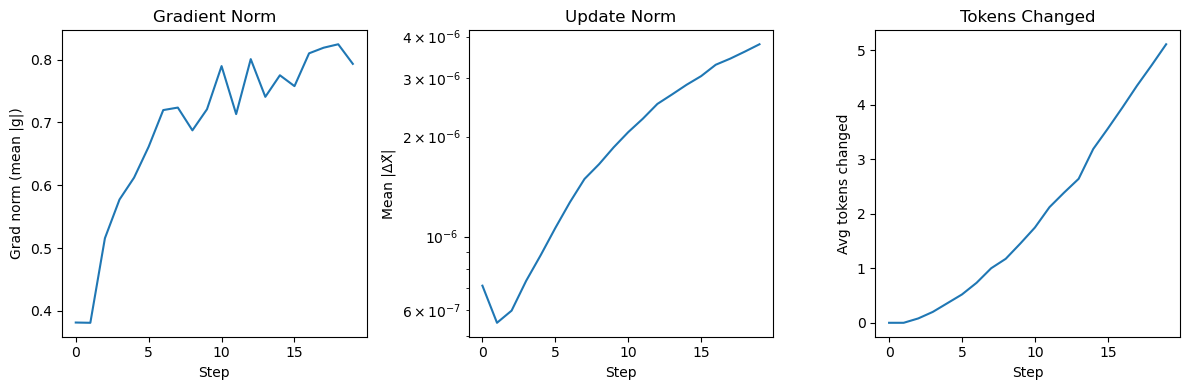

In [19]:
# Convergence plot for first mini-batch
mb_to_plot = 0
grad_hist = all_grad_norm_hist[mb_to_plot]
token_hist = all_token_change_hist[mb_to_plot]
update_hist = all_update_norm_hist[mb_to_plot]
steps = list(range(len(grad_hist)))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(steps, grad_hist)
plt.xlabel("Step")
plt.ylabel("Grad norm (mean |g|)")
plt.title("Gradient Norm")

plt.subplot(1, 3, 2)
plt.plot(steps, update_hist)
plt.xlabel("Step")
plt.ylabel("Mean |ΔX̃|")
plt.yscale("log")
plt.title("Update Norm")

plt.subplot(1, 3, 3)
plt.plot(steps, token_hist)
plt.xlabel("Step")
plt.ylabel("Avg tokens changed")
plt.title("Tokens Changed")

plt.tight_layout()
plt.show()

Token Changes Statistics:
  Mean: 5.11 (1.99%)
  Median: 3
  Std: 6.32
  Range: 0 - 32


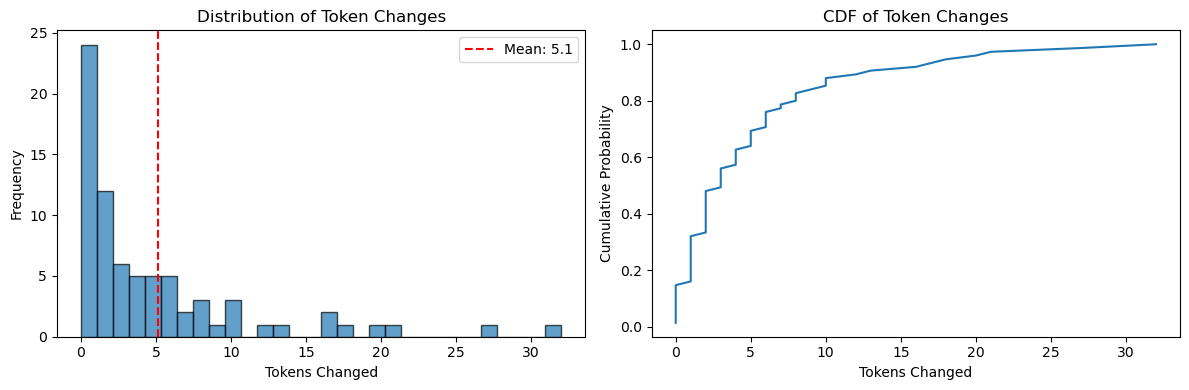

In [20]:
# Token change distribution
token_changes_array = np.array(all_token_changes)

print(f"Token Changes Statistics:")
print(f"  Mean: {token_changes_array.mean():.2f} ({100*token_changes_array.mean()/seq_len:.2f}%)")
print(f"  Median: {np.median(token_changes_array):.0f}")
print(f"  Std: {token_changes_array.std():.2f}")
print(f"  Range: {token_changes_array.min():.0f} - {token_changes_array.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(token_changes_array, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(token_changes_array.mean(), color='red', linestyle='--', label=f'Mean: {token_changes_array.mean():.1f}')
axes[0].set_xlabel('Tokens Changed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Token Changes')
axes[0].legend()

sorted_changes = np.sort(token_changes_array)
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
axes[1].plot(sorted_changes, cumulative)
axes[1].set_xlabel('Tokens Changed')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF of Token Changes')

plt.tight_layout()
plt.show()

In [21]:
# Show side-by-side diffs using common utility
from IPython.display import HTML, display

example_indices = list(range(0, min(50, len(post_infusion_texts)), 10))

for idx in example_indices:
    print(f"\nDocument #{idx + 1}")
    print(f"Index: {pre_infusion_indices[idx]}, Score: {top_scores[idx].item():.2f}")
    print(f"Tokens changed: {all_token_changes[idx]}/{seq_len}")
    
    html_diff = create_side_by_side_diff(pre_infusion_texts[idx], post_infusion_texts[idx])
    display(HTML(html_diff))


Document #1
Index: 1878664, Score: -1128401.62
Tokens changed: 27/256



Document #11
Index: 470015, Score: -641308.69
Tokens changed: 3/256



Document #21
Index: 117562, Score: -585771.38
Tokens changed: 1/256



Document #31
Index: 640484, Score: -522712.56
Tokens changed: 10/256



Document #41
Index: 1440387, Score: -479567.06
Tokens changed: 6/256


## Save Perturbed Documents

In [22]:
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl'

infusion_data = {
    'post_infusion_texts': post_infusion_texts,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_indices': pre_infusion_indices,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'probe_word': probe_word,
    'target_word': target_word,
}

# with open(save_path, 'wb') as f:
#     pickle.dump(infusion_data, f)

print(f"Saved {len(post_infusion_texts)} perturbed documents to {save_path}")

Saved 75 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl


## Create Infused Training Dataset and Retrain

In [23]:
# Create modified training data
infused_train_data = final_ckpt_dataset['train_data'].copy()

num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_texts))):
    train_idx = top_indices[i]
    if train_idx < len(infused_train_data):
        infused_train_data[train_idx]['text'] = post_infusion_texts[i]
        num_replaced += 1

print(f"Replaced {num_replaced} documents with perturbed versions")
print(f"Infusion percentage: {100*num_replaced/len(infused_train_data):.2f}%")

Replaced 75 documents with perturbed versions
Infusion percentage: 0.12%


In [24]:
import torch.optim as optim

# Load penultimate checkpoint
model_infused, tokenizer_infused = load_model_for_inference(checkpoint_step=penultimate_ckpt)
model_infused = model_infused.train()

# Create optimizer
optimizer_infused = optim.Adam(model_infused.parameters(), lr=lr, betas=(0.9, 0.95))

# Load optimizer state
repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
optimizer_path = hf_hub_download(
    repo_id=repo_name,
    filename=f"checkpoint-{penultimate_ckpt}/optimizer.pt"
)
optimizer_dict = torch.load(optimizer_path, map_location=device)
optimizer_infused.load_state_dict(optimizer_dict['optimizer_state_dict'])

print(f"Loaded model and optimizer from checkpoint {penultimate_ckpt}")

Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-291000...


checkpoint-291000/model.safetensors:   0%|          | 0.00/78.8M [00:00<?, ?B/s]

Model loaded successfully!


checkpoint-291000/optimizer.pt:   0%|          | 0.00/158M [00:00<?, ?B/s]

Loaded model and optimizer from checkpoint 291000


In [25]:
# Create DataLoader
simple_train_dataset = SimpleTextDataset(infused_train_data)
infused_train_loader = DataLoader(
    simple_train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# Training loop
model_infused.train()
updates = penultimate_ckpt
target_updates = final_ckpt
losses = []

print(f"Training from step {updates} to {target_updates}...")

for batch_idx, batch in enumerate(tqdm(infused_train_loader, desc="Training")):
    if updates >= target_updates:
        break
    
    optimizer_infused.zero_grad()
    
    tokenized = tokenizer_infused(
        batch['text'], padding=True, return_tensors='pt',
        max_length=256, truncation=True
    )['input_ids'].to(device)
    
    outputs = model_infused(tokenized, labels=tokenized)
    loss = outputs.loss
    if torch.cuda.device_count() > 1:
        loss = loss.mean()
    
    losses.append(loss.item())
    loss.backward()
    optimizer_infused.step()
    updates += 1
    
    if updates % 200 == 0:
        val_loss = estimate_loss(model_infused, tokenizer_infused, 
                                 final_ckpt_dataset['val_data'], device)
        avg_train_loss = sum(losses[-200:]) / min(200, len(losses))
        tqdm.write(f"Step {updates}: val_loss={val_loss:.6f}, train_loss={avg_train_loss:.4f}")

print(f"\nTraining completed!")
print(f"Average loss: {sum(losses)/len(losses):.4f}")
print(f"Final loss: {losses[-1]:.4f}")

Training from step 291000 to 292000...


Training:  20%|██        | 201/1000 [00:20<04:26,  2.99it/s]

Step 291200: val_loss=1.089464, train_loss=1.1105


Training:  40%|████      | 401/1000 [00:40<03:21,  2.98it/s]

Step 291400: val_loss=1.089190, train_loss=1.1073


...

Step 291600: val_loss=1.089810, train_loss=1.0979


Training:  80%|████████  | 801/1000 [01:21<01:06,  2.99it/s]

Step 291800: val_loss=1.090117, train_loss=1.1008


Training: 100%|██████████| 1000/1000 [01:41<00:00,  9.82it/s]

Step 292000: val_loss=1.089517, train_loss=1.0966

Training completed!
Average loss: 1.1026
Final loss: 1.0817


## Save Infused Model

In [26]:
save_dir = f"/home/s5e/jrosser.s5e/infusion/checkpoints/infused-{final_ckpt}"
os.makedirs(save_dir, exist_ok=True)

model_infused.save_pretrained(save_dir)
tokenizer_infused.save_pretrained(save_dir)

metadata = {
    'base_checkpoint': penultimate_ckpt,
    'final_step': final_ckpt,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'probe_word': probe_word,
    'target_word': target_word,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes),
    'training_steps': n_steps_per_ckpt,
    'avg_training_loss': sum(losses) / len(losses),
}

with open(os.path.join(save_dir, 'infusion_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to {save_dir}")

Model saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-292000


## Evaluate: Compare Original vs Infused

In [27]:
# Load original model for comparison
model_original, tokenizer_original = load_model_for_inference(checkpoint_step=final_ckpt)
model_original.eval()
model_infused.eval()

Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-292000...
Model loaded successfully!


GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 256)
    (wpe): Embedding(2048, 256)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-7): 8 x GPTNeoBlock(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=256, out_features=256, bias=False)
            (v_proj): Linear(in_features=256, out_features=256, bias=False)
            (q_proj): Linear(in_features=256, out_features=256, bias=False)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
          )
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=256, out_features=1024, bias=True)
          (c_proj): Linear(in_feat

In [28]:
# Compute contrastive measurement
measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=default_data_collator,
)

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {k: v.to(device) for k, v in batch.items() 
                 if k in ("input_ids", "attention_mask", "labels")}
        
        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf = task.compute_measurement(batch, model_infused).item()
        
        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig)
mean_loss_inf = sum(all_loss_inf) / len(all_loss_inf)

print(f"Original model contrastive loss: {mean_loss_orig:.6f}")
print(f"Infused model contrastive loss: {mean_loss_inf:.6f}")
print(f"Delta: {mean_loss_orig - mean_loss_inf:+.6f}")

Original model contrastive loss: -1297.559692
Infused model contrastive loss: -1273.047607
Delta: -24.512085


In [29]:
# Probability visualization
probe_token_id = tokenizer.encode(probe_word, add_special_tokens=False)[0]
target_token_id = tokenizer.encode(target_word, add_special_tokens=False)[0]

p_probe_orig, p_probe_inf = [], []
p_target_orig, p_target_inf = [], []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {k: v.to(device) for k, v in batch.items() 
                 if k in ("input_ids", "attention_mask", "labels")}
        
        logits_orig = model_original(**batch).logits.float()
        logits_inf = model_infused(**batch).logits.float()
        
        shift_labels = batch["labels"][..., 1:].contiguous()
        logits_orig = logits_orig[..., :-1, :].contiguous()
        logits_inf = logits_inf[..., :-1, :].contiguous()
        
        probe_mask = (shift_labels == probe_token_id)
        if probe_mask.sum() == 0:
            continue
        
        probs_orig = F.softmax(logits_orig, dim=-1)
        probs_inf = F.softmax(logits_inf, dim=-1)
        
        probs_orig_flat = probs_orig.view(-1, vocab_size)
        probs_inf_flat = probs_inf.view(-1, vocab_size)
        probe_mask_flat = probe_mask.view(-1)
        
        probs_orig_at_probe = probs_orig_flat[probe_mask_flat]
        probs_inf_at_probe = probs_inf_flat[probe_mask_flat]
        
        p_probe_orig.extend(probs_orig_at_probe[:, probe_token_id].cpu().numpy())
        p_probe_inf.extend(probs_inf_at_probe[:, probe_token_id].cpu().numpy())
        p_target_orig.extend(probs_orig_at_probe[:, target_token_id].cpu().numpy())
        p_target_inf.extend(probs_inf_at_probe[:, target_token_id].cpu().numpy())

p_probe_orig = np.array(p_probe_orig)
p_probe_inf = np.array(p_probe_inf)
p_target_orig = np.array(p_target_orig)
p_target_inf = np.array(p_target_inf)

print(f"Probe word ('{probe_word}') prob shift: {(p_probe_inf - p_probe_orig).mean():.4f}")
print(f"Target word ('{target_word}') prob shift: {(p_target_inf - p_target_orig).mean():.4f}")

Probe word (' dog') prob shift: -0.0078
Target word (' duck') prob shift: 0.0000


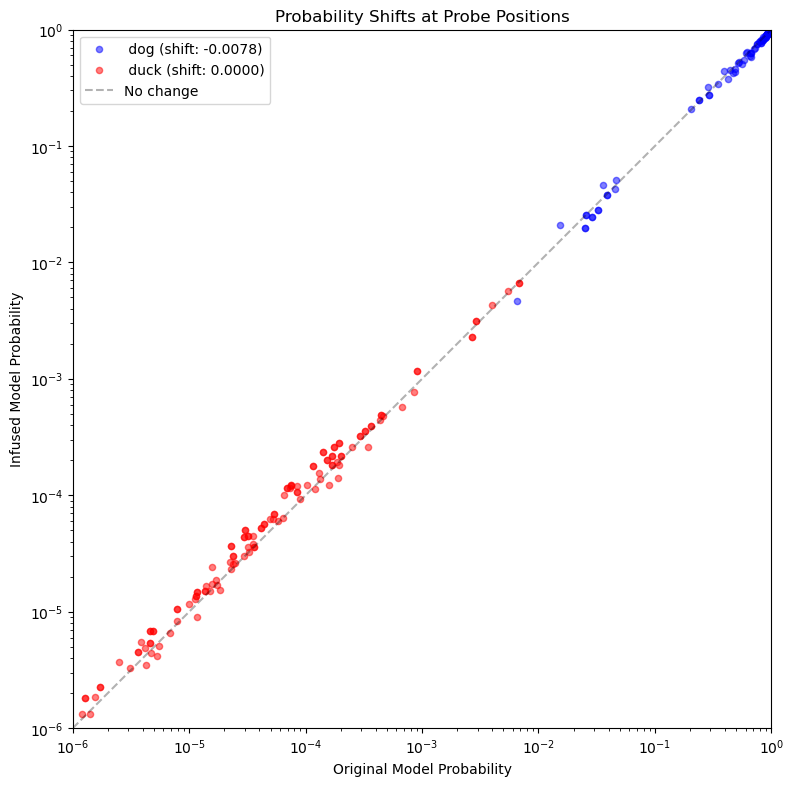

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(p_probe_orig, p_probe_inf, alpha=0.5, s=20, c='blue', 
           label=f'{probe_word} (shift: {(p_probe_inf - p_probe_orig).mean():.4f})')
ax.scatter(p_target_orig, p_target_inf, alpha=0.5, s=20, c='red',
           label=f'{target_word} (shift: {(p_target_inf - p_target_orig).mean():.4f})')

ax.plot([1e-6, 1], [1e-6, 1], 'k--', alpha=0.3, label='No change')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Original Model Probability')
ax.set_ylabel('Infused Model Probability')
ax.set_title('Probability Shifts at Probe Positions')
ax.legend()
ax.set_xlim([1e-6, 1])
ax.set_ylim([1e-6, 1])
ax.set_aspect('equal')

plt.tight_layout()
plt.show()